# Downtown LA Weather Analysis

This notebook is aligned to the assignment questions and now includes code for all generated visualizations directly inline.

## Data Source and Methodology

All analysis in this notebook is sourced from the SQLite database `database/weather.db`, not from hardcoded values. The database is populated by the ingestion pipeline, which combines:

- daily PDF weather reports parsed from `data/raw/pdfs`
- a cleaned 3-month CSV history from `data/raw/weather.csv`

The last-10-day analyses rely primarily on PDF rows because those files contain richer daily metadata such as normal temperatures and record highs/lows. The 3-month trend analysis uses a merged history that combines CSV coverage with PDF values where overlap exists.

Missing values are handled conservatively:

- blanks, `M`, dashes, and invalid values are converted to nulls
- broken or unreadable PDFs are skipped instead of crashing the pipeline
- if a PDF does not contain a normal average temperature, the notebook uses the CSV departure field as a fallback to estimate normal average temperature

Source: SQLite `weather_data` table created by the ingestion scripts in `scripts/`.


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

base_dir = Path.cwd().resolve().parents[0]
scripts_dir = base_dir / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from analysis import load_weather_data, build_analysis_views

weather_df = load_weather_data()
last_10_days, merged_history = build_analysis_views(weather_df)
chart_data = last_10_days.dropna(subset=['date']).copy()
trend = merged_history.dropna(subset=['date', 'avg_temp']).copy()
trend['rolling_7d_avg'] = trend['avg_temp'].rolling(window=7, min_periods=1).mean()
weather_df.head()

,id,date,max_temp,min_temp,avg_temp,precipitation,departure,normal_max_temp,normal_min_temp,normal_avg_temp,record_high_temp,record_low_temp,record_high_year,record_low_year,qc_flag,source_file,source
0,11,2026-01-01,68.0,53.0,60.5,1.31,2.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,weather.csv,csv
1,12,2026-01-02,66.0,53.0,59.5,0.30,1.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,weather.csv,csv
2,13,2026-01-03,63.0,55.0,59.0,0.54,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,weather.csv,csv
3,14,2026-01-04,60.0,54.0,57.0,0.32,-1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,weather.csv,csv
4,15,2026-01-05,65.0,50.0,57.5,NaN,-0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,weather.csv,csv


## 1. Hottest day in the last 10 days

We use the PDF-backed last-10-day view because the PDFs contain the most detailed day-level normals and record context.

In [2]:
hottest_day = last_10_days.dropna(subset=['max_temp']).sort_values(['max_temp', 'date'], ascending=[False, True]).iloc[0]
hottest_day[['date', 'max_temp', 'normal_max_temp', 'high_vs_normal', 'record_high_temp', 'record_high_year']]

date                2026-03-12 00:00:00
max_temp                           92.0
normal_max_temp                    70.0
high_vs_normal                     22.0
record_high_temp                   93.0
record_high_year                 2007.0
Name: 3, dtype: object

### Chart 1. Last 10 Days Observed vs Normal High

This chart compares the observed daily high from the PDF reports against the normal daily high for the same dates.

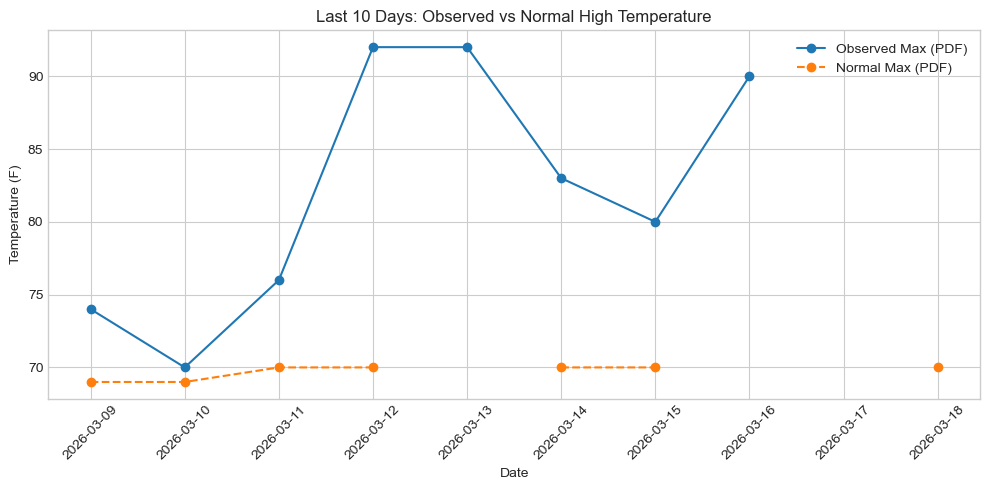

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(chart_data['date'], chart_data['max_temp'], marker='o', label='Observed Max (PDF)')
plt.plot(chart_data['date'], chart_data['normal_max_temp'], marker='o', linestyle='--', label='Normal Max (PDF)')
plt.title('Last 10 Days: Observed vs Normal High Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Biggest swing between the high and low

This highlights the most volatile day in the last 10 PDF observations.

In [4]:
biggest_swing = last_10_days.dropna(subset=['temp_swing']).sort_values(['temp_swing', 'date'], ascending=[False, True]).iloc[0]
biggest_swing[['date', 'max_temp', 'min_temp', 'temp_swing']]

date          2026-03-12 00:00:00
max_temp                     92.0
min_temp                     56.0
temp_swing                   36.0
Name: 3, dtype: object

### Chart 2. Last 10 Days Temperature Swing

This chart shows the day-by-day spread between the observed high and low temperatures.

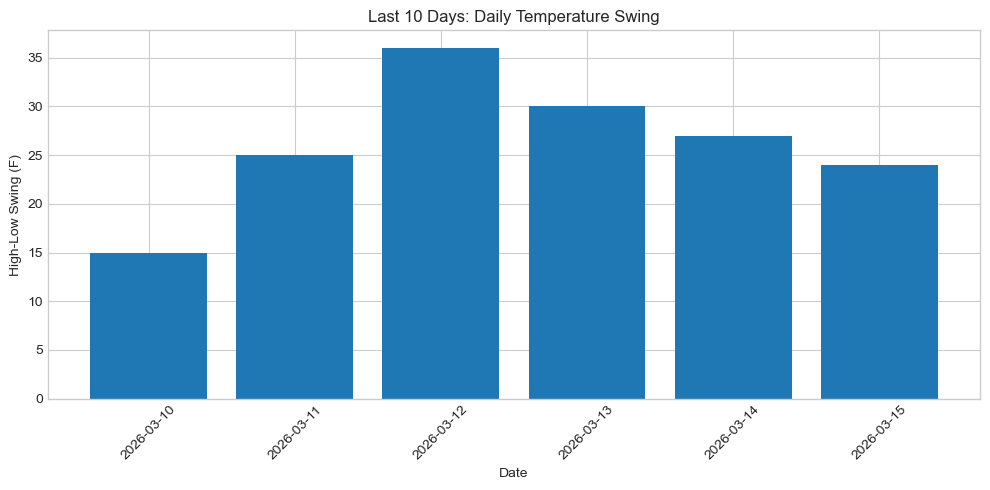

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(chart_data['date'], chart_data['temp_swing'])
plt.title('Last 10 Days: Daily Temperature Swing')
plt.xlabel('Date')
plt.ylabel('High-Low Swing (F)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. How many of the last 10 days were warmer than average?

We compare each day's observed average temperature to the daily normal average. If the PDF does not provide normal average explicitly, the CSV departure-based normal is used as a fallback.

In [6]:
warmer_than_average = last_10_days[
    last_10_days['avg_temp'].notna()
    & last_10_days['effective_normal_avg_temp'].notna()
    & (last_10_days['avg_temp'] > last_10_days['effective_normal_avg_temp'])
]
warmer_than_average[['date', 'avg_temp', 'effective_normal_avg_temp', 'avg_vs_normal']]

,date,avg_temp,effective_normal_avg_temp,avg_vs_normal
1,2026-03-10,62.5,60.7,1.8
2,2026-03-11,63.5,60.8,2.7
3,2026-03-12,74.0,60.9,13.1
4,2026-03-13,77.0,60.9,16.1
5,2026-03-14,69.5,61.0,8.5
6,2026-03-15,68.0,61.1,6.9
8,2026-03-17,81.0,61.3,19.7


## 4. Record highs and lows

The table below checks whether each of the last 10 PDF days tied, broke, or came close to a record.

In [7]:
record_view = last_10_days[[
    'date', 'max_temp', 'record_high_temp', 'record_high_year',
    'min_temp', 'record_low_temp', 'record_low_year'
]].copy()
record_view['high_gap_to_record'] = record_view['record_high_temp'] - record_view['max_temp']
record_view['low_gap_to_record'] = record_view['min_temp'] - record_view['record_low_temp']
record_view

,date,max_temp,record_high_temp,record_high_year,min_temp,record_low_temp,record_low_year,high_gap_to_record,low_gap_to_record
0,2026-03-09,74.0,90.0,1934.0,NaN,NaN,NaN,16.0,NaN
1,2026-03-10,70.0,96.0,1916.0,55.0,38.0,1893.0,26.0,17.0
2,2026-03-11,76.0,93.0,1916.0,51.0,39.0,1917.0,17.0,12.0
3,2026-03-12,92.0,93.0,2007.0,56.0,36.0,1893.0,1.0,20.0
4,2026-03-13,92.0,92.0,2026.0,62.0,52.0,1895.0,0.0,10.0
5,2026-03-14,83.0,93.0,2015.0,56.0,39.0,1895.0,10.0,17.0
6,2026-03-15,80.0,92.0,2015.0,56.0,37.0,1880.0,12.0,19.0
7,2026-03-16,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-03-18,NaN,87.0,1997.0,NaN,62.0,2015.0,NaN,NaN


## 5. Past 3-month trends

For the broader trend view, we use the merged 3-month history.

In [8]:
trend[['date', 'avg_temp', 'rolling_7d_avg']].tail(15)

,date,avg_temp,rolling_7d_avg
54,2026-03-03,63.0,65.785714
55,2026-03-04,60.5,66.000000
56,2026-03-05,64.0,65.642857
57,2026-03-06,62.0,64.428571
58,2026-03-07,66.5,64.285714
59,2026-03-08,71.5,64.357143
60,2026-03-09,64.0,64.500000
61,2026-03-10,62.5,64.428571
62,2026-03-11,63.5,64.857143
63,2026-03-12,74.0,66.285714


### Chart 3. Past 3 Months Temperature Trend

This plot shows the day-level average temperature along with a 7-day rolling average to smooth the short-term noise.

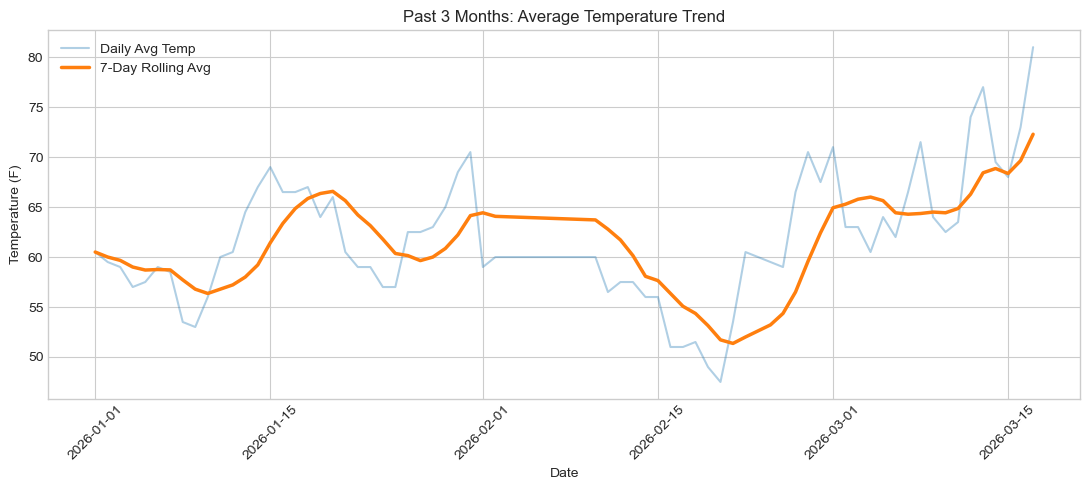

In [9]:
plt.figure(figsize=(11, 5))
plt.plot(trend['date'], trend['avg_temp'], alpha=0.35, label='Daily Avg Temp')
plt.plot(trend['date'], trend['rolling_7d_avg'], linewidth=2.5, label='7-Day Rolling Avg')
plt.title('Past 3 Months: Average Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Chart 4. Past 3 Months Monthly Precipitation

This bar chart aggregates the precipitation totals by month to show how wet or dry each month was.

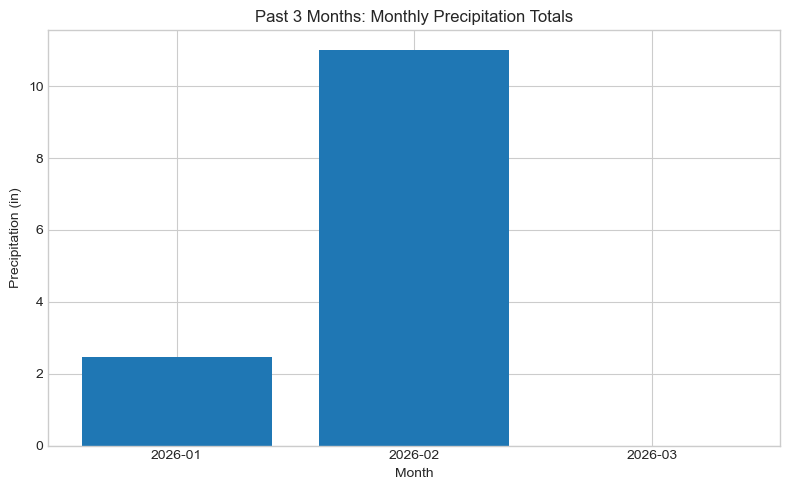

In [10]:
monthly = trend.assign(month=trend['date'].dt.to_period('M').dt.to_timestamp())
monthly = monthly.groupby('month', as_index=False)['precipitation'].sum()
plt.figure(figsize=(8, 5))
plt.bar(monthly['month'].dt.strftime('%Y-%m'), monthly['precipitation'].fillna(0))
plt.title('Past 3 Months: Monthly Precipitation Totals')
plt.xlabel('Month')
plt.ylabel('Precipitation (in)')
plt.tight_layout()
plt.show()

## Additional Visualizations From Earlier Analysis

The sections below add the earlier three charts as inline notebook code as well, so all generated visualizations are available in one place.

### Chart 5. Daily Precipitation

This is the day-level precipitation bar chart across the broader merged weather history.

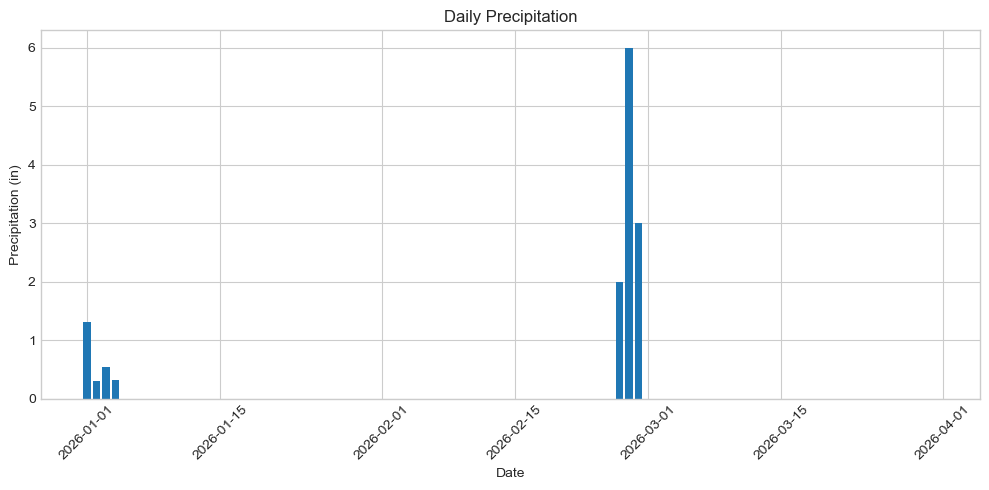

In [11]:
precip_data = merged_history.dropna(subset=['date']).copy()
plt.figure(figsize=(10, 5))
plt.bar(precip_data['date'], precip_data['precipitation'].fillna(0))
plt.title('Daily Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation (in)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 6. Daily Max and Min Temperature

This line chart shows the full 3-month history of daily high and low temperatures.

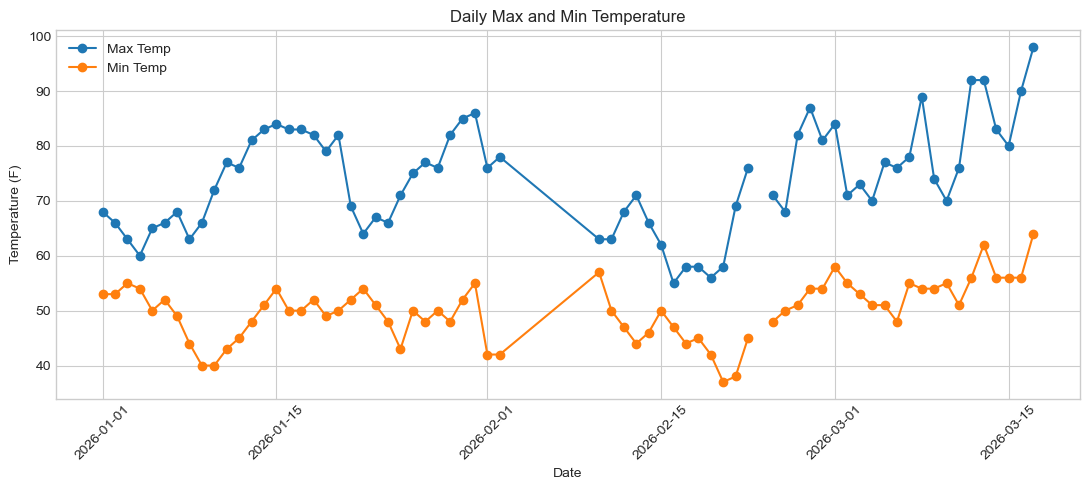

In [12]:
temp_lines = merged_history.dropna(subset=['date']).copy()
plt.figure(figsize=(11, 5))
plt.plot(temp_lines['date'], temp_lines['max_temp'], marker='o', label='Max Temp')
plt.plot(temp_lines['date'], temp_lines['min_temp'], marker='o', label='Min Temp')
plt.title('Daily Max and Min Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (F)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Chart 7. 3-Day Rolling Average Temperature Trend

This recreates the earlier rolling-temperature chart using a 3-day average instead of the newer 7-day view.

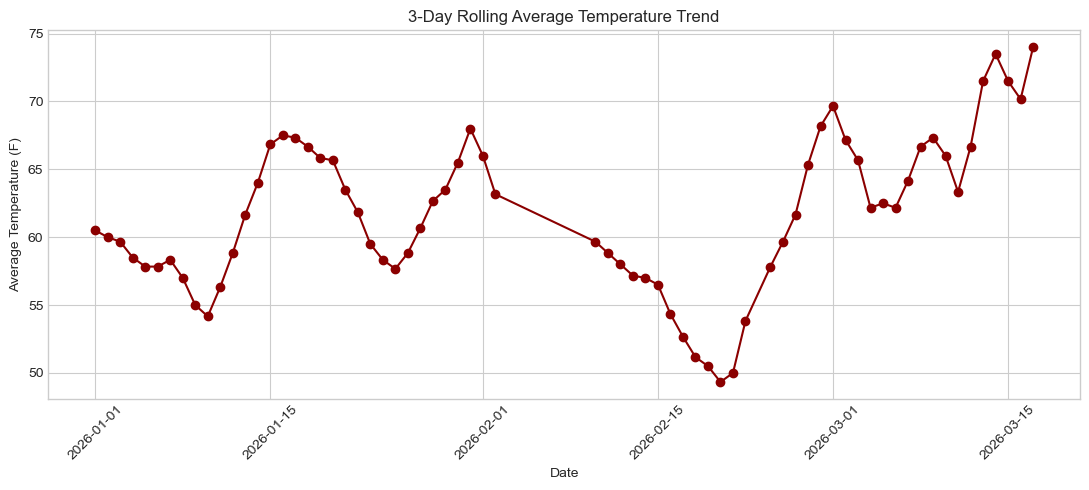

In [13]:
rolling3 = merged_history.dropna(subset=['date', 'avg_temp']).copy()
rolling3 = rolling3.set_index('date')['avg_temp'].rolling(window=3, min_periods=1).mean()
plt.figure(figsize=(11, 5))
plt.plot(rolling3.index, rolling3.values, color='darkred', marker='o')
plt.title('3-Day Rolling Average Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Average Temperature (F)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

This analysis shows that the most recent PDF-backed period was notably warm relative to normal seasonal conditions in Downtown LA. Several of the last 10 days were warmer than average, one day showed the largest daily temperature swing, and at least one recent day came very close to or matched a historical record high.

The broader 3-month view adds context by showing how average temperature and precipitation changed over time. Together, the short-term PDF analysis and longer-term CSV history provide both daily detail and seasonal trend coverage.

Overall, the notebook answers the stakeholder questions directly from the database-backed weather pipeline and demonstrates that the results are reproducible, explainable, and grounded in the ingested data.
